In [123]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.preprocessing import LabelEncoder

In [124]:
print("="*70)
print("FLIGHT FARE PREDICTION USING MACHINE LEARNING")
print("="*70)

print("""
Objective:
The aim of this project is to analyse flight details and build
a machine learning model that predicts the ticket price based
on different flight features.
""")

FLIGHT FARE PREDICTION USING MACHINE LEARNING

Objective:
The aim of this project is to analyse flight details and build
a machine learning model that predicts the ticket price based
on different flight features.



In [125]:
df = pd.read_csv("Data_Train.csv")

print("\nDataset loaded successfully.")


Dataset loaded successfully.


In [126]:
print("="*70)
print("FIRST FIVE RECORDS")
print("="*70)

display(df.head())

FIRST FIVE RECORDS


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [127]:
print("="*70)
print("LAST FIVE RECORDS")
print("="*70)

display(df.tail())

LAST FIVE RECORDS


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [128]:
rows, columns = df.shape

print("="*70)
print("DATASET SHAPE")
print("="*70)

print(f"Total Rows : {rows}")
print(f"Total Columns : {columns}")

DATASET SHAPE
Total Rows : 10683
Total Columns : 11


In [129]:
print("="*70)
print("COLUMN NAMES")
print("="*70)

for col in df.columns:
    print(col)

COLUMN NAMES
Airline
Date_of_Journey
Source
Destination
Route
Dep_Time
Arrival_Time
Duration
Total_Stops
Additional_Info
Price


In [130]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [131]:
print("="*70)
print("STATISTICAL SUMMARY")
print("="*70)

display(df.describe(include="all"))

STATISTICAL SUMMARY


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683,10683.000000
unique,12,44,5,6,128,222,1343,368,5,10,NaN
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info,NaN
freq,3849,504,4537,4537,2376,233,423,550,5625,8345,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9087.064121
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4611.359167
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1759.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5277.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8372.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12373.000000


In [132]:
print("="*70)
print("MISSING VALUES")
print("="*70)

print(df.isnull().sum())

MISSING VALUES
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64


In [133]:
print("="*70)
print("DUPLICATE RECORDS")
print("="*70)

print(df.duplicated().sum())

DUPLICATE RECORDS
220


In [134]:
print("="*70)
print("DATASET DETAILS")
print("="*70)

print(f"Total Flights : {len(df)}")

print(f"Total Features : {len(df.columns)}")

print("Target Column : Price")

DATASET DETAILS
Total Flights : 10683
Total Features : 11
Target Column : Price


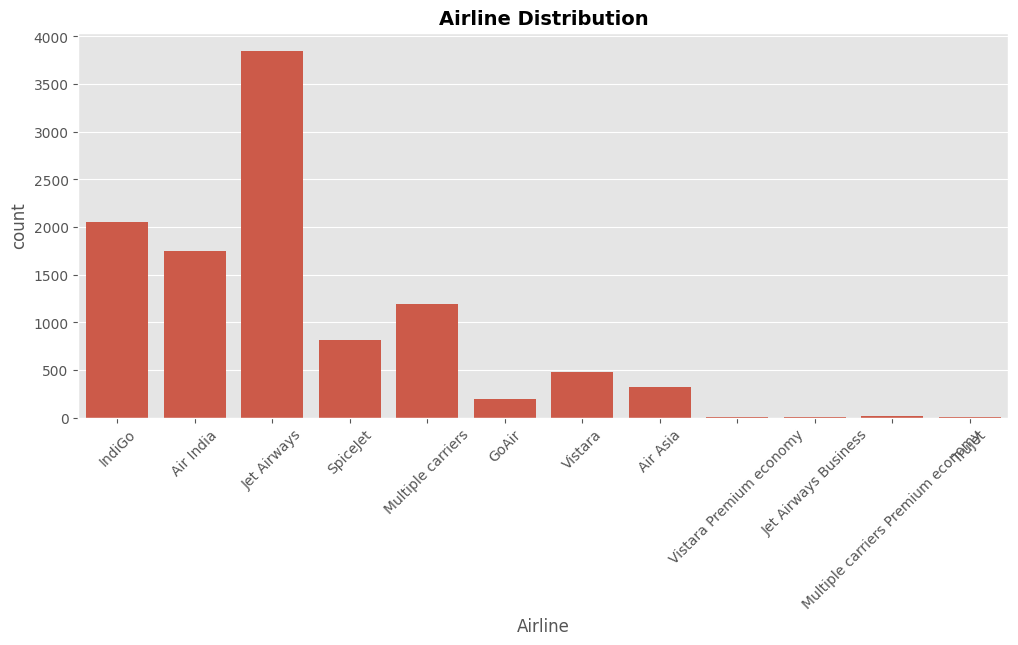

In [135]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Airline"
)

plt.title("Airline Distribution",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=45)

plt.show()

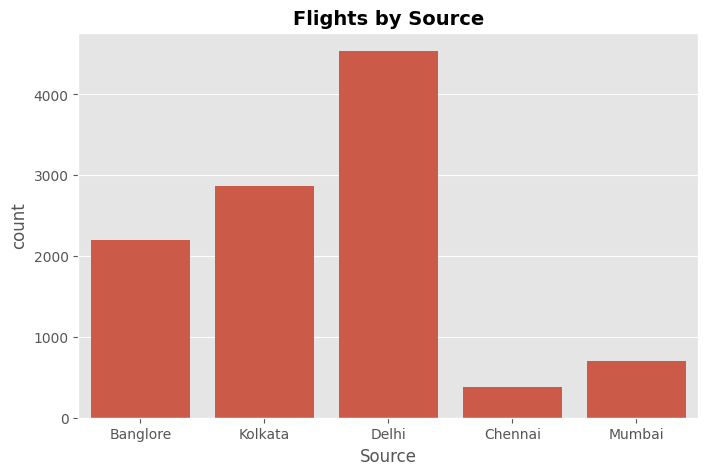

In [136]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Source"
)

plt.title("Flights by Source",
          fontsize=14,
          fontweight="bold")

plt.show()

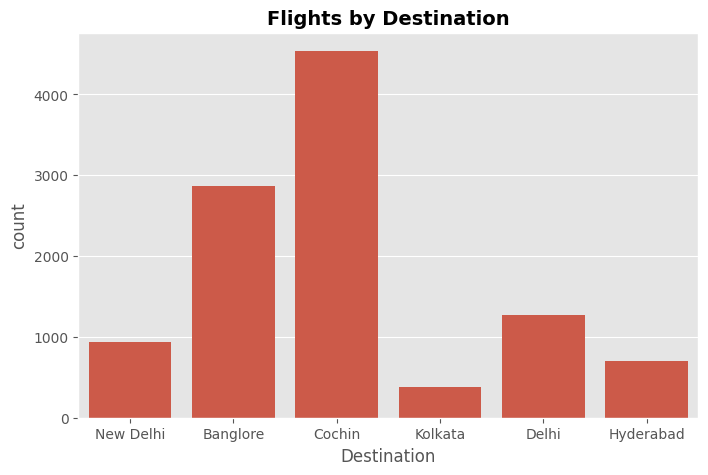

In [137]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Destination"
)

plt.title("Flights by Destination",
          fontsize=14,
          fontweight="bold")

plt.show()

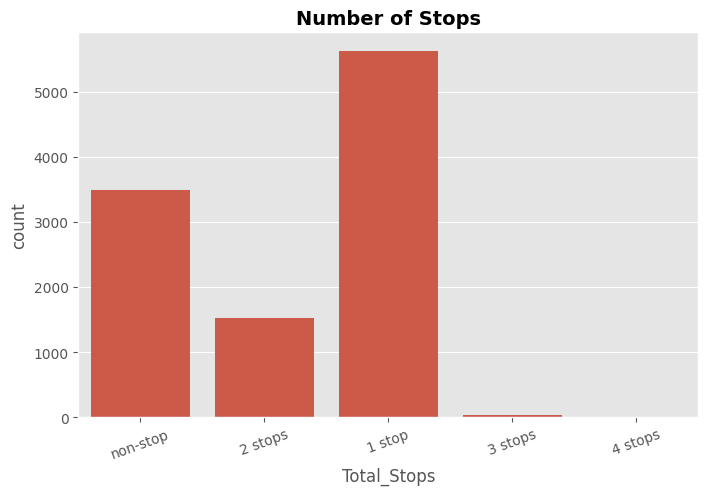

In [138]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Total_Stops"
)

plt.title("Number of Stops",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=20)

plt.show()

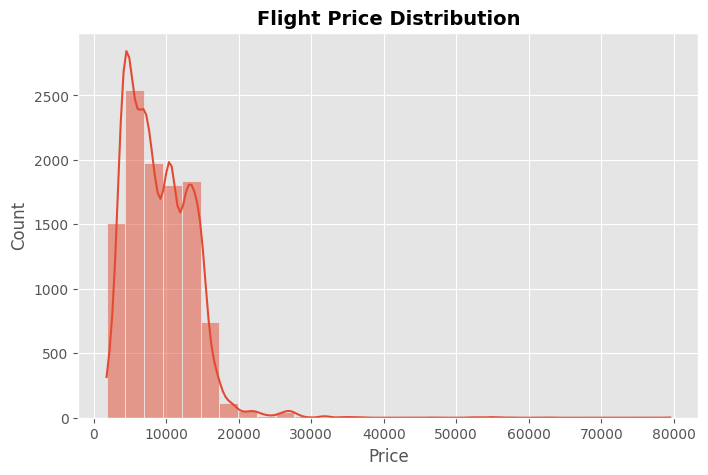

In [139]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Price"],
    bins=30,
    kde=True
)

plt.title("Flight Price Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

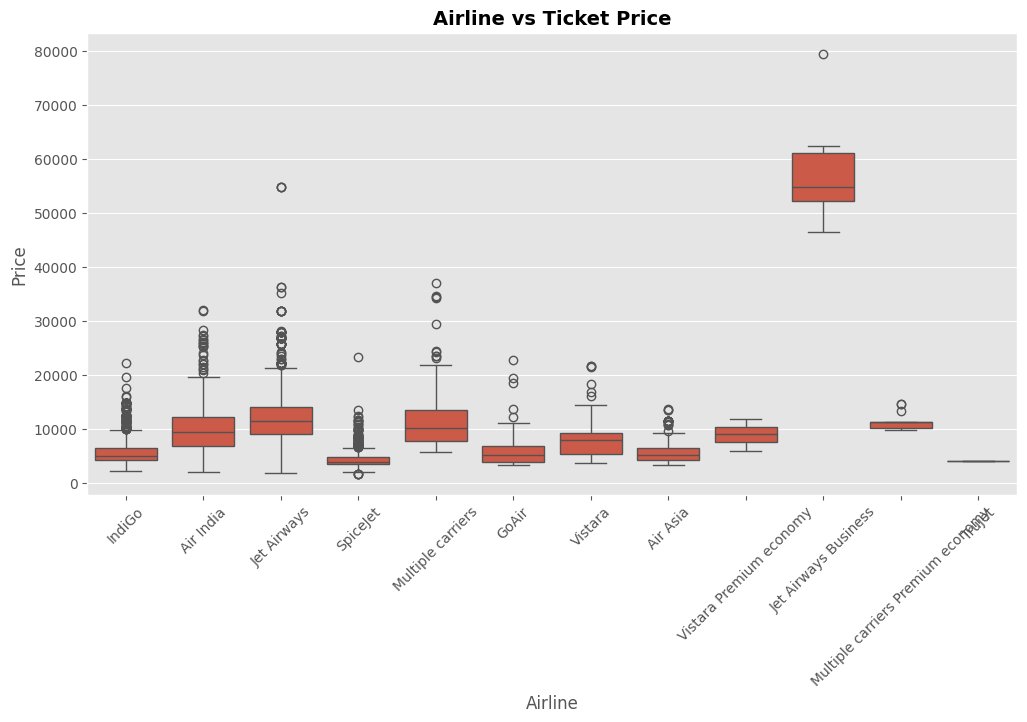

In [140]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Airline",
    y="Price"
)

plt.title("Airline vs Ticket Price",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=45)

plt.show()

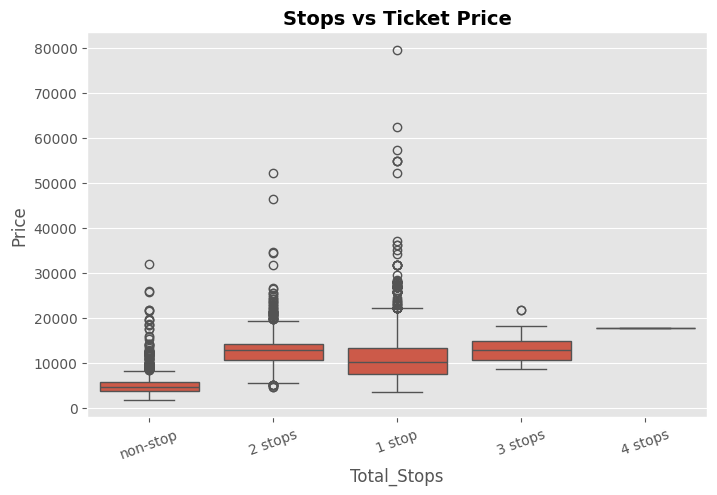

In [141]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Total_Stops",
    y="Price"
)

plt.title("Stops vs Ticket Price",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=20)

plt.show()

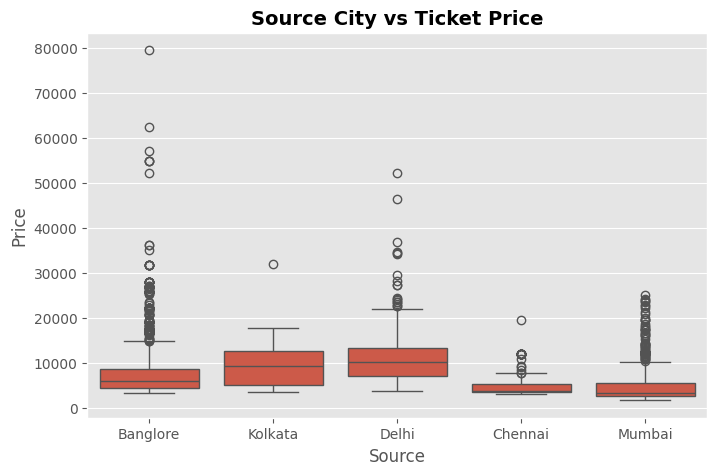

In [142]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Source",
    y="Price"
)

plt.title("Source City vs Ticket Price",
          fontsize=14,
          fontweight="bold")

plt.show()

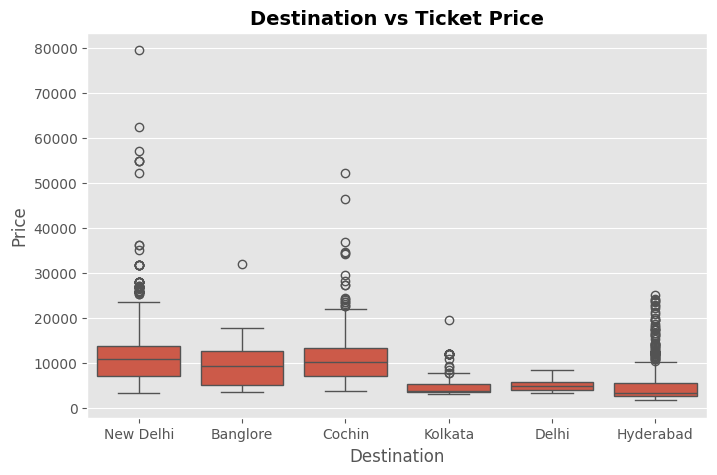

In [143]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Destination",
    y="Price"
)

plt.title("Destination vs Ticket Price",
          fontsize=14,
          fontweight="bold")

plt.show()

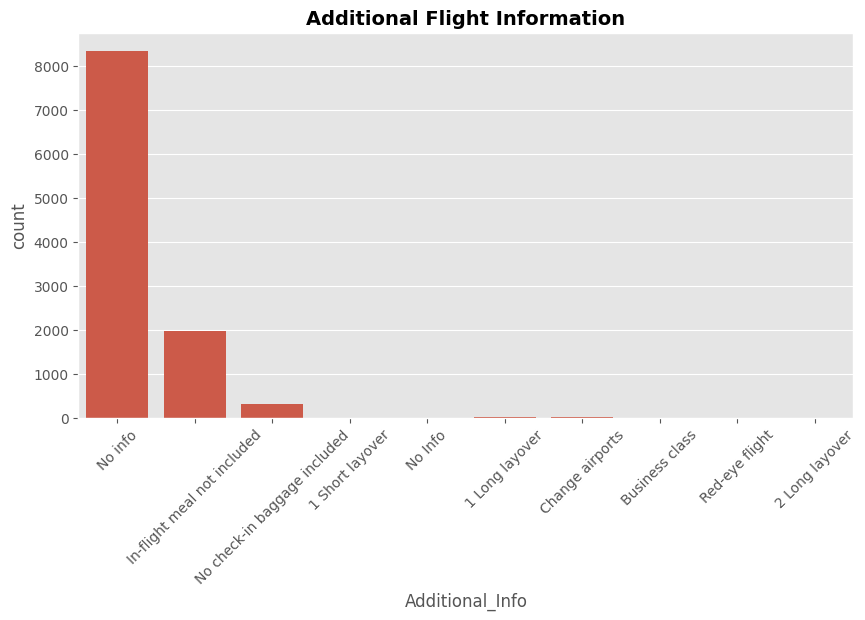

In [144]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Additional_Info"
)

plt.title("Additional Flight Information",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=45)

plt.show()

In [145]:
df["Journey_Day"] = pd.to_datetime(df["Date_of_Journey"]).dt.day

df["Journey_Month"] = pd.to_datetime(df["Date_of_Journey"]).dt.month

df.drop("Date_of_Journey", axis=1, inplace=True)

/tmp/ipykernel_2131/3049469652.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Journey_Day"] = pd.to_datetime(df["Date_of_Journey"]).dt.day
/tmp/ipykernel_2131/3049469652.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Journey_Month"] = pd.to_datetime(df["Date_of_Journey"]).dt.month


In [146]:
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour

df["Dep_Min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

df.drop("Dep_Time", axis=1, inplace=True)

/tmp/ipykernel_2131/2042232613.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
/tmp/ipykernel_2131/2042232613.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_Min"] = pd.to_datetime(df["Dep_Time"]).dt.minute


In [147]:
df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour

df["Arrival_Min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop("Arrival_Time", axis=1, inplace=True)

/tmp/ipykernel_2131/1895686991.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
/tmp/ipykernel_2131/1895686991.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_Min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute


In [148]:
duration = df["Duration"].astype(str)

df["Duration_Hours"] = duration.str.extract(r'(\d+)h').fillna(0).astype(int)

df["Duration_Minutes"] = duration.str.extract(r'(\d+)m').fillna(0).astype(int)

df.drop("Duration", axis=1, inplace=True)

In [149]:
print("="*70)
print("UPDATED DATASET")
print("="*70)

display(df.head())

UPDATED DATASET


,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


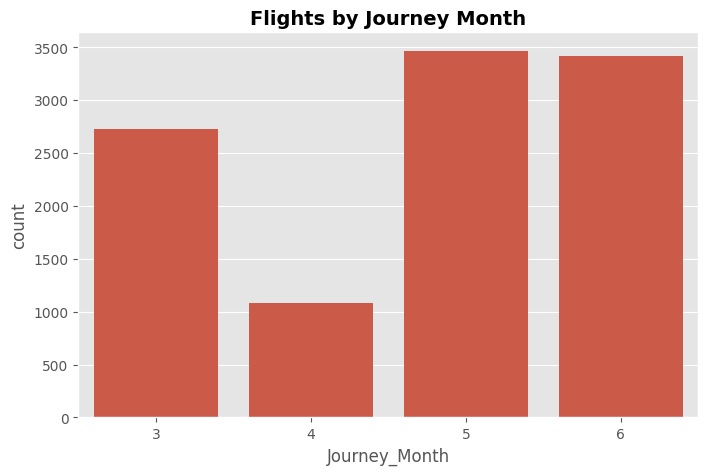

In [150]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Journey_Month"
)

plt.title("Flights by Journey Month",
          fontsize=14,
          fontweight="bold")

plt.show()

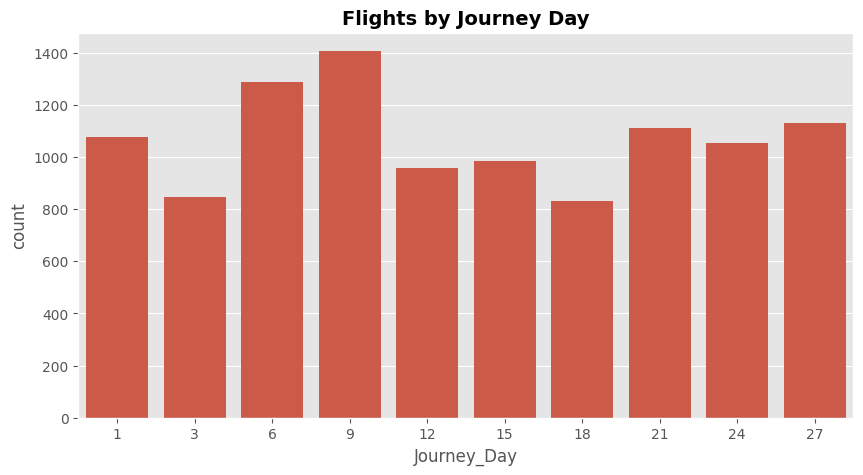

In [151]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Journey_Day"
)

plt.title("Flights by Journey Day",
          fontsize=14,
          fontweight="bold")

plt.show()

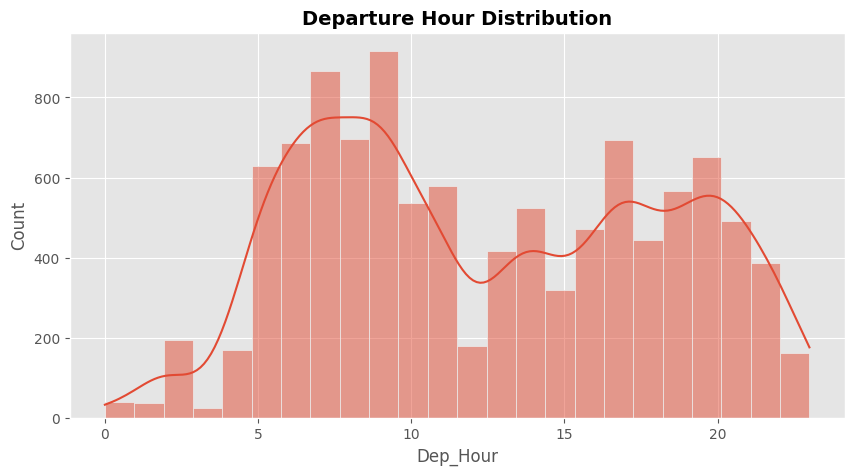

In [152]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Dep_Hour"],
    bins=24,
    kde=True
)

plt.title("Departure Hour Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

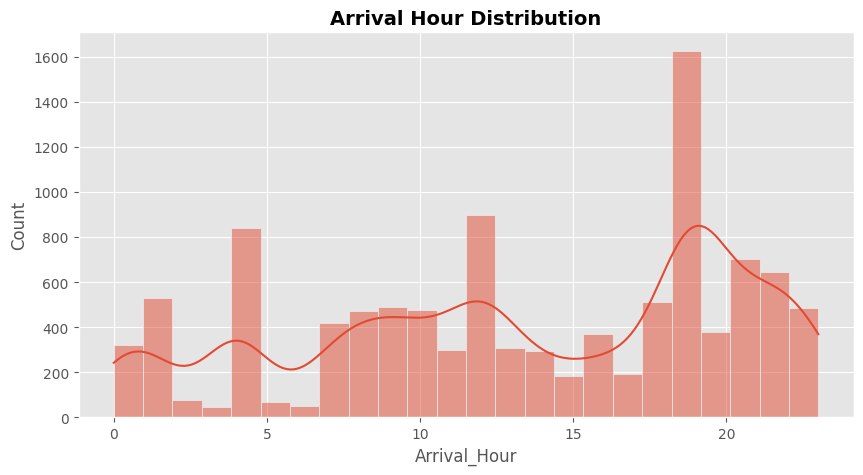

In [153]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Arrival_Hour"],
    bins=24,
    kde=True
)

plt.title("Arrival Hour Distribution",
          fontsize=14,
          fontweight="bold")

plt.show()

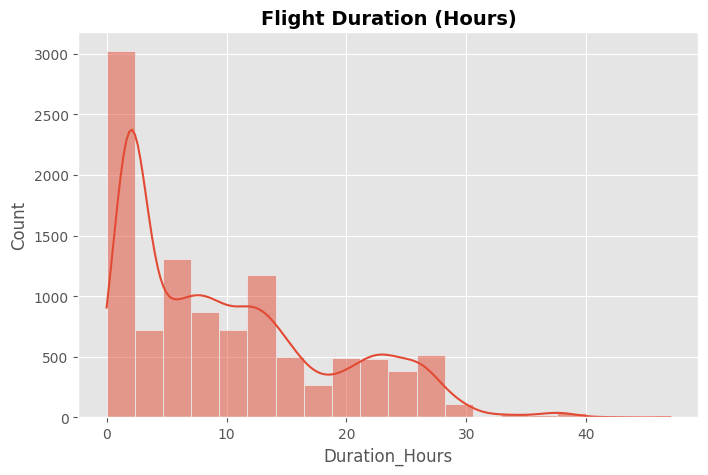

In [154]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Duration_Hours"],
    bins=20,
    kde=True
)

plt.title("Flight Duration (Hours)",
          fontsize=14,
          fontweight="bold")

plt.show()

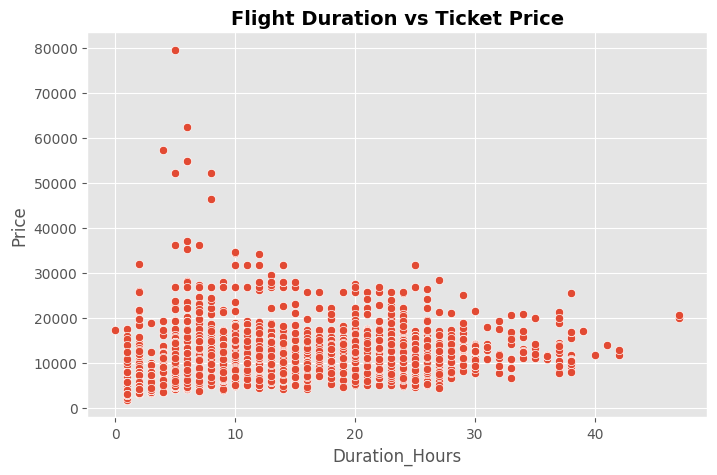

In [155]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Duration_Hours",
    y="Price"
)

plt.title("Flight Duration vs Ticket Price",
          fontsize=14,
          fontweight="bold")

plt.show()

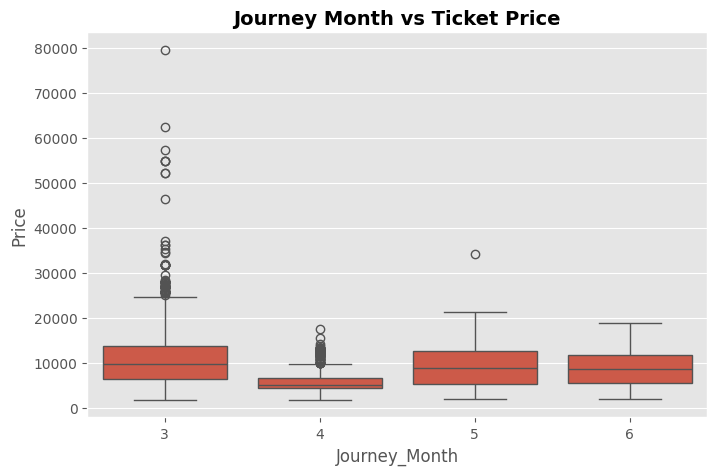

In [156]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Journey_Month",
    y="Price"
)

plt.title("Journey Month vs Ticket Price",
          fontsize=14,
          fontweight="bold")

plt.show()

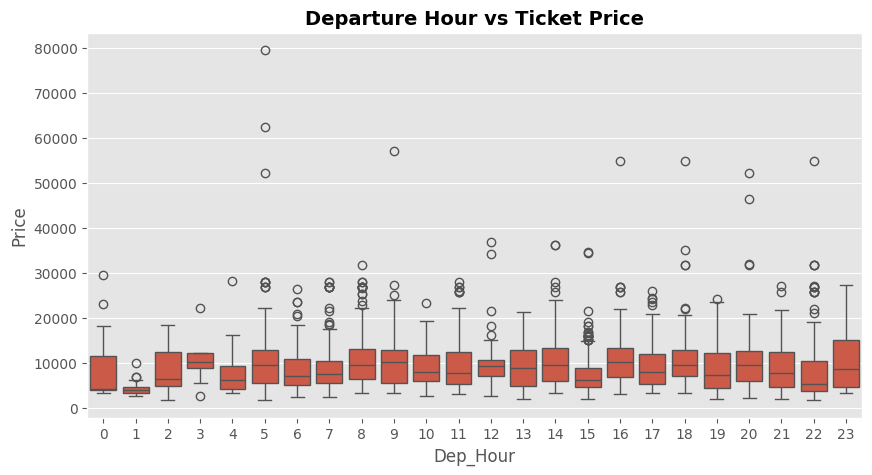

In [157]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Dep_Hour",
    y="Price"
)

plt.title("Departure Hour vs Ticket Price",
          fontsize=14,
          fontweight="bold")

plt.show()

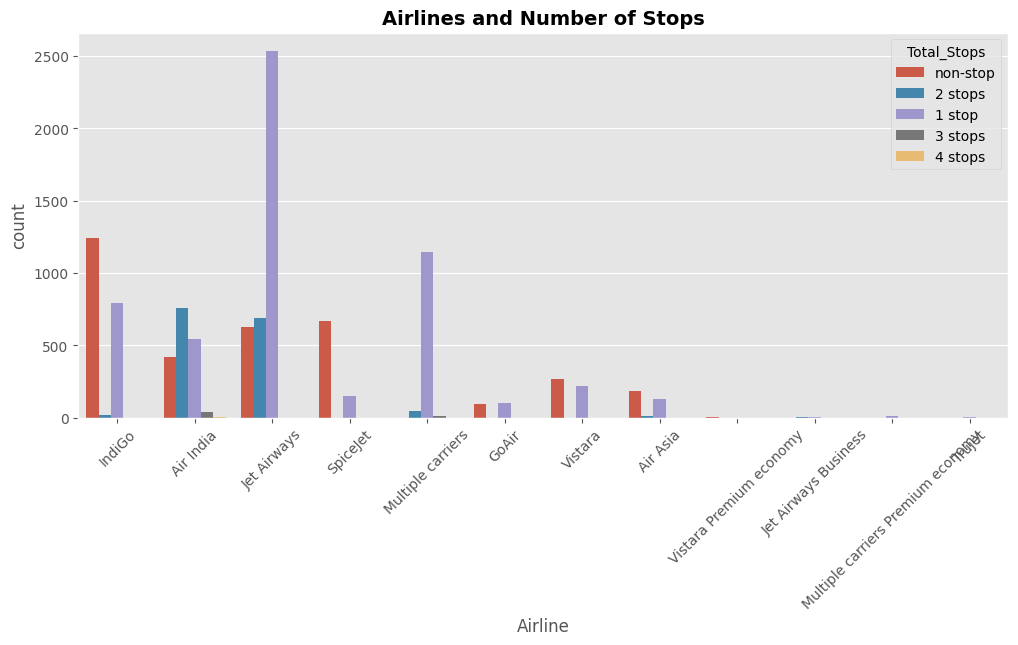

In [158]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Airline",
    hue="Total_Stops"
)

plt.title("Airlines and Number of Stops",
          fontsize=14,
          fontweight="bold")

plt.xticks(rotation=45)

plt.show()

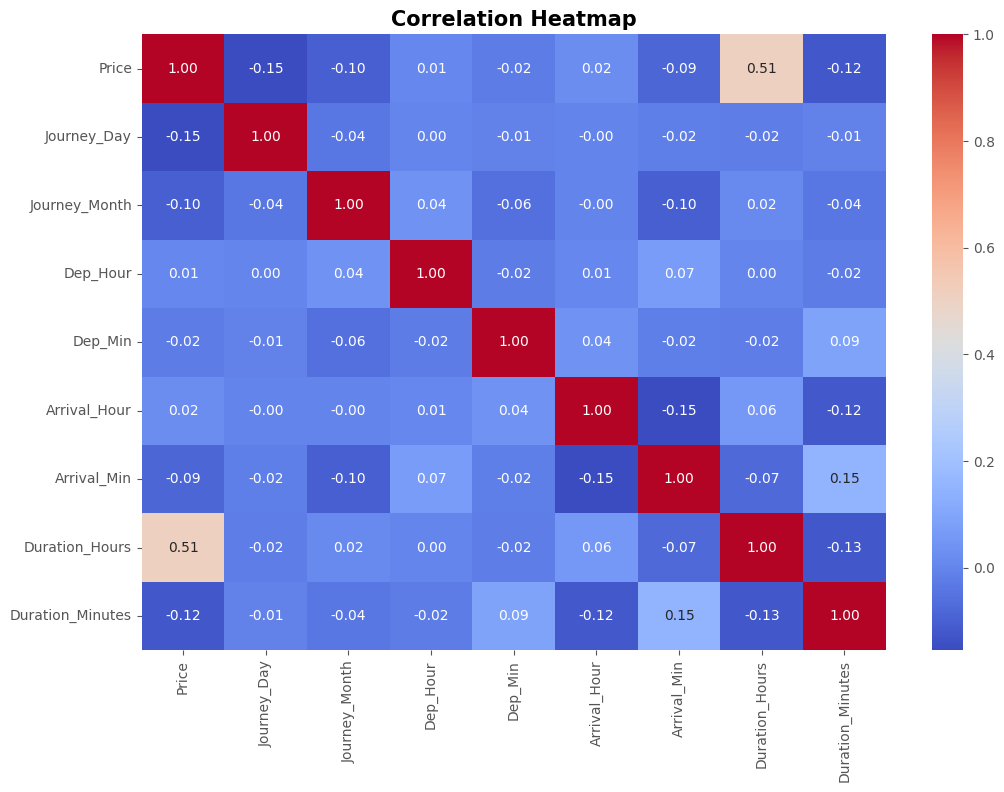

In [159]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap",
          fontsize=15,
          fontweight="bold")

plt.show()

In [160]:
print("="*70)
print("DATASET INSIGHTS")
print("="*70)

print(f"Average Ticket Price : {round(df['Price'].mean(),2)}")

print(f"Highest Ticket Price : {df['Price'].max()}")

print(f"Lowest Ticket Price : {df['Price'].min()}")

print(f"Average Flight Duration (Hours) : {round(df['Duration_Hours'].mean(),2)}")

print(f"Total Airlines : {df['Airline'].nunique()}")

print(f"Total Source Cities : {df['Source'].nunique()}")

print(f"Total Destinations : {df['Destination'].nunique()}")

DATASET INSIGHTS
Average Ticket Price : 9087.06
Highest Ticket Price : 79512
Lowest Ticket Price : 1759
Average Flight Duration (Hours) : 10.25
Total Airlines : 12
Total Source Cities : 5
Total Destinations : 6


In [161]:
print("="*70)
print("MISSING VALUES")
print("="*70)

print(df.isnull().sum())

df.dropna(inplace=True)

print("\nMissing Values After Cleaning")

print(df.isnull().sum())

MISSING VALUES
Airline             0
Source              0
Destination         0
Route               1
Total_Stops         1
Additional_Info     0
Price               0
Journey_Day         0
Journey_Month       0
Dep_Hour            0
Dep_Min             0
Arrival_Hour        0
Arrival_Min         0
Duration_Hours      0
Duration_Minutes    0
dtype: int64

Missing Values After Cleaning
Airline             0
Source              0
Destination         0
Route               0
Total_Stops         0
Additional_Info     0
Price               0
Journey_Day         0
Journey_Month       0
Dep_Hour            0
Dep_Min             0
Arrival_Hour        0
Arrival_Min         0
Duration_Hours      0
Duration_Minutes    0
dtype: int64


In [162]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Total_Stops",
    "Additional_Info"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("="*70)
print("CATEGORICAL DATA ENCODED")
print("="*70)

CATEGORICAL DATA ENCODED


In [163]:
X = df.drop("Price", axis=1)

y = df["Price"]

print("="*70)
print("FEATURES")
print("="*70)

display(X.head())

print("="*70)
print("TARGET")
print("="*70)

display(y.head())

FEATURES


,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Minutes
0,3,0,5,18,4,8,24,3,22,20,1,10,2,50
1,1,3,0,84,1,8,1,5,5,50,13,15,7,25
2,4,2,1,118,1,8,9,6,9,25,4,25,19,0
3,3,3,0,91,0,8,12,5,18,5,23,30,5,25
4,3,0,5,29,0,8,1,3,16,50,21,35,4,45


TARGET


,Price
0,3897
1,7662
2,13882
3,6218
4,13302


In [164]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("="*70)
print("TRAIN TEST SPLIT")
print("="*70)

print("Training Data :", X_train.shape)

print("Testing Data  :", X_test.shape)

TRAIN TEST SPLIT
Training Data : (8545, 14)
Testing Data  : (2137, 14)


In [165]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("="*70)
print("DATA SCALING COMPLETED")
print("="*70)

DATA SCALING COMPLETED


In [166]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

print("="*70)
print("LINEAR REGRESSION MODEL CREATED")
print("="*70)

LINEAR REGRESSION MODEL CREATED


In [167]:
model.fit(X_train, y_train)

print("="*70)
print("MODEL TRAINED SUCCESSFULLY")
print("="*70)

MODEL TRAINED SUCCESSFULLY


In [168]:
y_pred = model.predict(X_test)

print("="*70)
print("PREDICTIONS GENERATED")
print("="*70)

PREDICTIONS GENERATED


In [169]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.round(2)
})

print("="*70)
print("ACTUAL VS PREDICTED")
print("="*70)

display(comparison.head(10))

ACTUAL VS PREDICTED


,Actual Price,Predicted Price
0,16655,9388.68
1,4959,10742.60
2,9187,11336.80
3,3858,4489.87
4,12898,8923.55
5,10529,10972.37
6,16079,9650.11
7,7229,6326.24
8,10844,9326.95
9,16289,10311.81


In [170]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("="*70)
print("MEAN ABSOLUTE ERROR")
print("="*70)

print(mae)

MEAN ABSOLUTE ERROR
2482.735438673904


In [171]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("="*70)
print("MEAN SQUARED ERROR")
print("="*70)

print(mse)

MEAN SQUARED ERROR
12169855.145105843


In [172]:
rmse = np.sqrt(mse)

print("="*70)
print("ROOT MEAN SQUARED ERROR")
print("="*70)

print(rmse)

ROOT MEAN SQUARED ERROR
3488.5319469808273


In [173]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("="*70)
print("R2 SCORE")
print("="*70)

print(r2)

R2 SCORE
0.4355893073394548


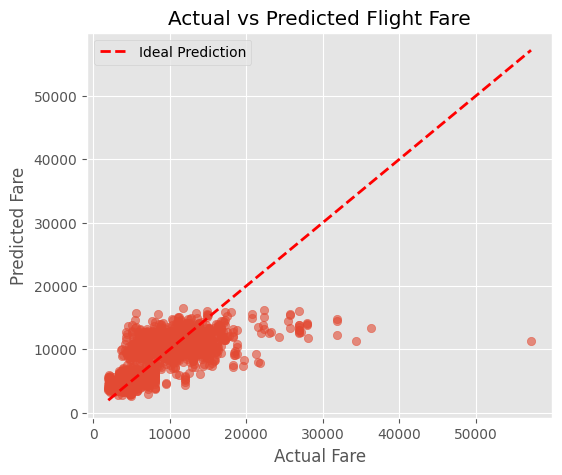

In [174]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred, alpha=0.6)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label="Ideal Prediction"
)

plt.xlabel("Actual Fare")

plt.ylabel("Predicted Fare")

plt.title("Actual vs Predicted Flight Fare")

plt.legend()

plt.grid(True)

plt.show()

In [175]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance["Importance"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("="*70)
print("TOP IMPORTANT FEATURES")
print("="*70)

display(feature_importance)

TOP IMPORTANT FEATURES


,Feature,Coefficient,Importance
4,Total_Stops,-2110.532996,2110.532996
12,Duration_Hours,1293.252130,1293.252130
6,Journey_Day,-580.774884,580.774884
7,Journey_Month,-401.894122,401.894122
1,Source,-301.443181,301.443181
5,Additional_Info,277.259081,277.259081
2,Destination,249.522569,249.522569
3,Route,-206.719791,206.719791
13,Duration_Minutes,-202.800187,202.800187
10,Arrival_Hour,-182.636719,182.636719


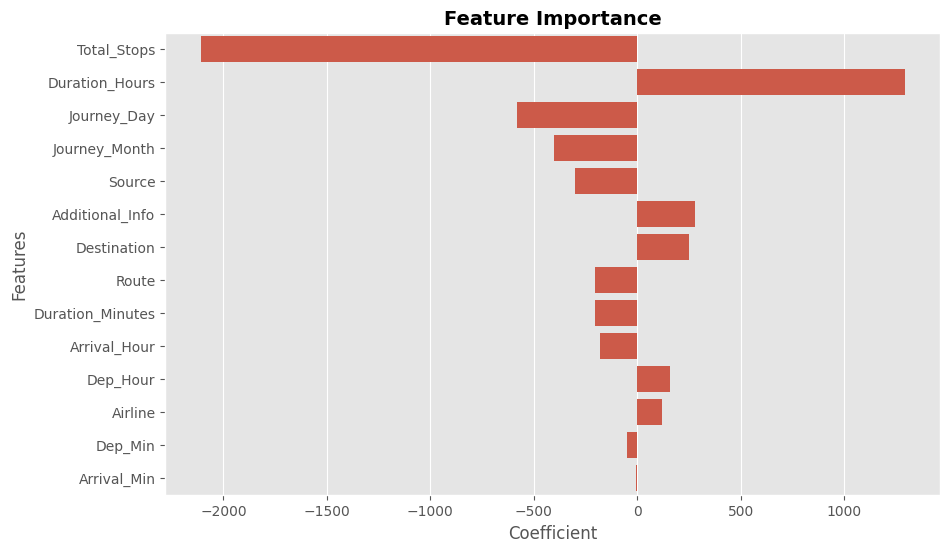

In [176]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Coefficient")

plt.ylabel("Features")

plt.show()

In [177]:
import pickle

pickle.dump(
    model,
    open("flight_price_model.pkl","wb")
)

print("="*70)
print("MODEL SAVED SUCCESSFULLY")
print("="*70)

MODEL SAVED SUCCESSFULLY


In [178]:
loaded_model = pickle.load(
    open("flight_price_model.pkl","rb")
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [179]:
sample_prediction = loaded_model.predict(X_test[:1])

print("="*70)
print("SAMPLE FLIGHT PRICE PREDICTION")
print("="*70)

print(f"Predicted Flight Price : ₹{sample_prediction[0]:.2f}")

SAMPLE FLIGHT PRICE PREDICTION
Predicted Flight Price : ₹9388.68


In [180]:
print("="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"Dataset Name        : Flight Fare Prediction")
print(f"Total Flights       : {len(df)}")
print(f"Total Features      : {len(df.columns)}")
print(f"Machine Learning    : Linear Regression")
print(f"Target Variable     : Price")
print(f"R2 Score            : {r2:.4f}")
print(f"MAE                 : {mae:.2f}")
print(f"RMSE                : {rmse:.2f}")

PROJECT SUMMARY
Dataset Name        : Flight Fare Prediction
Total Flights       : 10682
Total Features      : 15
Machine Learning    : Linear Regression
Target Variable     : Price
R2 Score            : 0.4356
MAE                 : 2482.74
RMSE                : 3488.53


In [181]:
print("="*70)
print("CONCLUSION")
print("="*70)

print("""
This project analysed flight information and built a machine learning
model to predict ticket prices.

Different preprocessing techniques such as missing value handling,
feature engineering and label encoding were applied before training
the model.

Linear Regression was used to predict the flight fare.

The model was evaluated using Mean Absolute Error (MAE),
Mean Squared Error (MSE), Root Mean Squared Error (RMSE)
and R² Score.

The model can estimate ticket prices using information like
airline, source, destination, number of stops, journey date
and flight duration.

This type of prediction can help customers compare prices
and assist airlines in analysing pricing patterns.
""")

CONCLUSION

This project analysed flight information and built a machine learning
model to predict ticket prices.

Different preprocessing techniques such as missing value handling,
feature engineering and label encoding were applied before training
the model.

Linear Regression was used to predict the flight fare.

The model was evaluated using Mean Absolute Error (MAE),
Mean Squared Error (MSE), Root Mean Squared Error (RMSE)
and R² Score.

The model can estimate ticket prices using information like
airline, source, destination, number of stops, journey date
and flight duration.

This type of prediction can help customers compare prices
and assist airlines in analysing pricing patterns.



In [182]:
print("="*70)
print("KEY INSIGHTS")
print("="*70)

print("""
• Flight duration has a noticeable impact on ticket price.

• Flights with more stops generally have different pricing patterns
  compared to non-stop flights.

• Ticket prices vary across airlines.

• Source and destination cities influence airfare.

• Journey month and departure time also contribute to price variation.

• Machine Learning can be used to estimate flight fares
  before booking.
""")

KEY INSIGHTS

• Flight duration has a noticeable impact on ticket price.

• Flights with more stops generally have different pricing patterns
  compared to non-stop flights.

• Ticket prices vary across airlines.

• Source and destination cities influence airfare.

• Journey month and departure time also contribute to price variation.

• Machine Learning can be used to estimate flight fares
  before booking.



In [183]:
print("="*70)
print("END OF PROJECT")
print("="*70)

print("""
Flight Fare Prediction using Machine Learning

Tools Used:
• Python
• Pandas
• NumPy
• Matplotlib
• Seaborn
• Scikit-learn

Thank You!
""")

END OF PROJECT

Flight Fare Prediction using Machine Learning

Tools Used:
• Python
• Pandas
• NumPy
• Matplotlib
• Seaborn
• Scikit-learn

Thank You!

